# US Diabetes Health Disparities — Multivariate Analysis

**Project:** US Diabetes Health Disparities Analysis  
**Notebook:** 04_multivariate_analysis.ipynb  
**Author:** Adam Bailes  
**Date:** July 2026  
**Purpose:** Logistic regression to identify factors independently 
associated with high diabetes burden after controlling for confounders

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# Load the analysis-ready merged dataset
df = pd.read_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\merged_analysis_ready.csv'
)

# Ensure LocationID is zero-padded string
df['LocationID'] = df['LocationID'].astype(str).str.zfill(5)

print(df.shape)
print(df.columns.tolist())

(2956, 28)
['LocationID', 'BPHIGH', 'DIABETES', 'HIGHCHOL', 'LPA', 'OBESITY', 'pop_total', 'pop_white', 'pop_black', 'pop_aian', 'pop_asian', 'pop_nhpi', 'pop_multirace', 'pop_poverty_total', 'pop_below_poverty', 'pct_below_poverty', 'county_name', 'median_household_income', 'pct_white', 'pct_black', 'pct_aian', 'pct_asian', 'pct_nhpi', 'pct_multirace', 'pct_hispanic', 'income_quintile', 'urban_rural_code', 'urban_rural']


In [2]:
# Create binary high-burden outcome variable
# 1 = county diabetes prevalence above national mean
# 0 = county diabetes prevalence at or below national mean
national_mean = df['DIABETES'].mean()

df['high_diabetes'] = (df['DIABETES'] > national_mean).astype(int)

# Confirm the split
print(f'National mean: {national_mean:.2f}%')
print(f'High burden counties: {df["high_diabetes"].sum()}')
print(f'Low burden counties: {(df["high_diabetes"] == 0).sum()}')
print(f'Split: {df["high_diabetes"].mean():.1%} high burden')

National mean: 13.64%
High burden counties: 1307
Low burden counties: 1649
Split: 44.2% high burden


## Analytical Approach

### Why Linear Regression First
DIABETES is a continuous variable (county-level prevalence %). 
Linear regression predicts the actual prevalence value rather than 
a binary high/low classification, producing more interpretable 
coefficients: each coefficient represents the change in diabetes 
prevalence (in percentage points) associated with a one-unit change 
in the predictor, holding all other variables constant.

### Non-Linearity Concern
Residual plots in 02_feature_transformation.ipynb flagged potential 
non-linearity for BPHIGH (C-shaped residuals) and OBESITY/HIGHCHOL 
(fan-shaped residuals). These will be checked in the multivariate 
context and transformed if needed before finalizing the model.

### Predictor Variables
- Health measures: BPHIGH, OBESITY, LPA, HIGHCHOL
- Race/ethnicity: pct_black, pct_hispanic, pct_aian
- Socioeconomic: pct_below_poverty, median_household_income
- Geography: urban_rural_code

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define predictor variables and outcome
predictors = [
    'BPHIGH', 'OBESITY', 'LPA', 'HIGHCHOL',
    'pct_black', 'pct_hispanic', 'pct_aian',
    'pct_below_poverty', 'median_household_income',
    'urban_rural_code'
]

X = df[predictors]
y = df['DIABETES']

print(f'Predictors: {X.shape[1]}')
print(f'Outcome: {y.shape[0]} counties')
print(f'\nMissing values in predictors:')
print(X.isnull().sum())

Predictors: 10
Outcome: 2956 counties

Missing values in predictors:
BPHIGH                     0
OBESITY                    0
LPA                        0
HIGHCHOL                   0
pct_black                  0
pct_hispanic               0
pct_aian                   0
pct_below_poverty          0
median_household_income    0
urban_rural_code           0
dtype: int64


In [5]:
# Standardize predictors to a common scale
# This ensures coefficients are comparable across variables
# with different units (% vs dollars vs codes)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Fit linear regression model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R²: {r2:.3f}')
print(f'RMSE: {rmse:.3f} percentage points')

R²: 0.923
RMSE: 0.742 percentage points


In [6]:
# Display model coefficients
# Standardized coefficients allow comparison across predictors
coef_df = pd.DataFrame({
    'Predictor': predictors,
    'Coefficient': model.coef_.round(3)
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

              Predictor  Coefficient
                 BPHIGH        1.568
           pct_hispanic        0.596
      pct_below_poverty        0.446
               HIGHCHOL        0.363
              pct_black        0.357
                    LPA        0.332
               pct_aian        0.279
                OBESITY        0.128
       urban_rural_code        0.093
median_household_income       -0.024


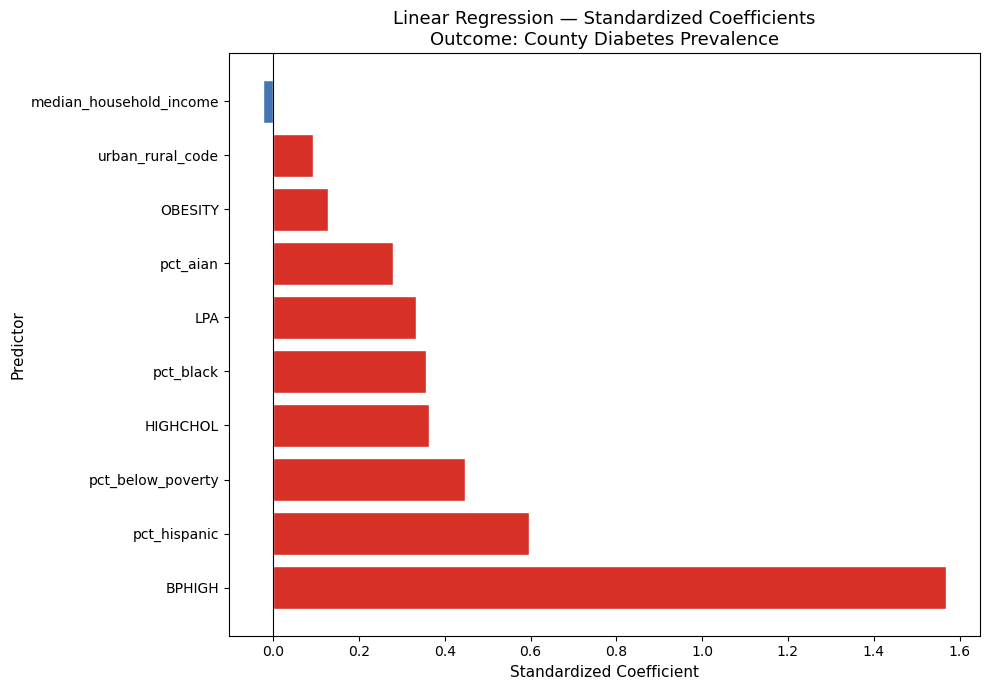

Chart saved


In [9]:
# Plot standardized coefficients
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#d73027' if x > 0 else '#4575b4' 
          for x in coef_df['Coefficient']]

ax.barh(coef_df['Predictor'], coef_df['Coefficient'],
        color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression — Standardized Coefficients\nOutcome: County Diabetes Prevalence',
             fontsize=13)
ax.set_xlabel('Standardized Coefficient', fontsize=11)
ax.set_ylabel('Predictor', fontsize=11)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\linear_regression_coefficients.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

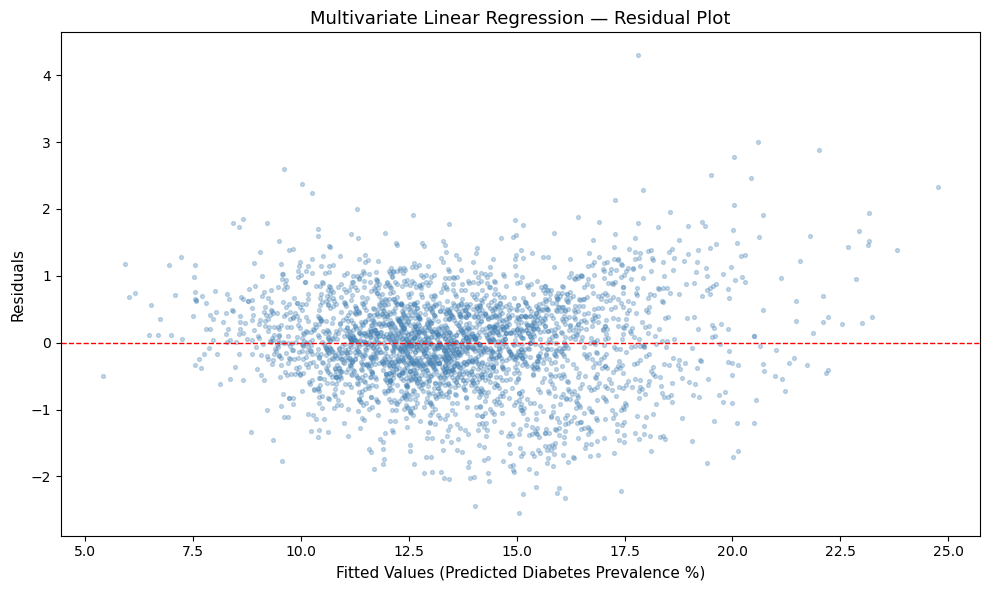

Chart saved


In [8]:
# Calculate residuals from the model on the full dataset
y_pred_full = model.predict(X_scaled)
residuals = y - y_pred_full

# Plot residuals against fitted values
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(y_pred_full, residuals, alpha=0.3, s=8, color='steelblue')
ax.axhline(0, color='red', linestyle='dashed', linewidth=1)
ax.set_title('Multivariate Linear Regression — Residual Plot', fontsize=13)
ax.set_xlabel('Fitted Values (Predicted Diabetes Prevalence %)', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\multivariate_residual_plot.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

In [10]:
# Add polynomial term for BPHIGH to address non-linearity
# BPHIGH² allows the model to fit a curve rather than a straight line
df['BPHIGH_squared'] = df['BPHIGH'] ** 2

# Redefine predictors with BPHIGH² added
predictors_poly = [
    'BPHIGH', 'BPHIGH_squared', 'OBESITY', 'LPA', 'HIGHCHOL',
    'pct_black', 'pct_hispanic', 'pct_aian',
    'pct_below_poverty', 'median_household_income',
    'urban_rural_code'
]

X_poly = df[predictors_poly]
y = df['DIABETES']

# Standardize the expanded predictor set
scaler_poly = StandardScaler()
X_poly_scaled = scaler_poly.fit_transform(X_poly)

# Split into training and test sets using the same random state
# for a fair comparison with the original model
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly_scaled, y, test_size=0.2, random_state=42
)

# Fit the polynomial model
model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

# Evaluate on test set
y_pred_p = model_poly.predict(X_test_p)
r2_poly = r2_score(y_test_p, y_pred_p)
rmse_poly = np.sqrt(mean_squared_error(y_test_p, y_pred_p))

print(f'Original model  R²: {r2:.3f}  RMSE: {rmse:.3f}')
print(f'Polynomial model R²: {r2_poly:.3f}  RMSE: {rmse_poly:.3f}')

Original model  R²: 0.923  RMSE: 0.742
Polynomial model R²: 0.925  RMSE: 0.736


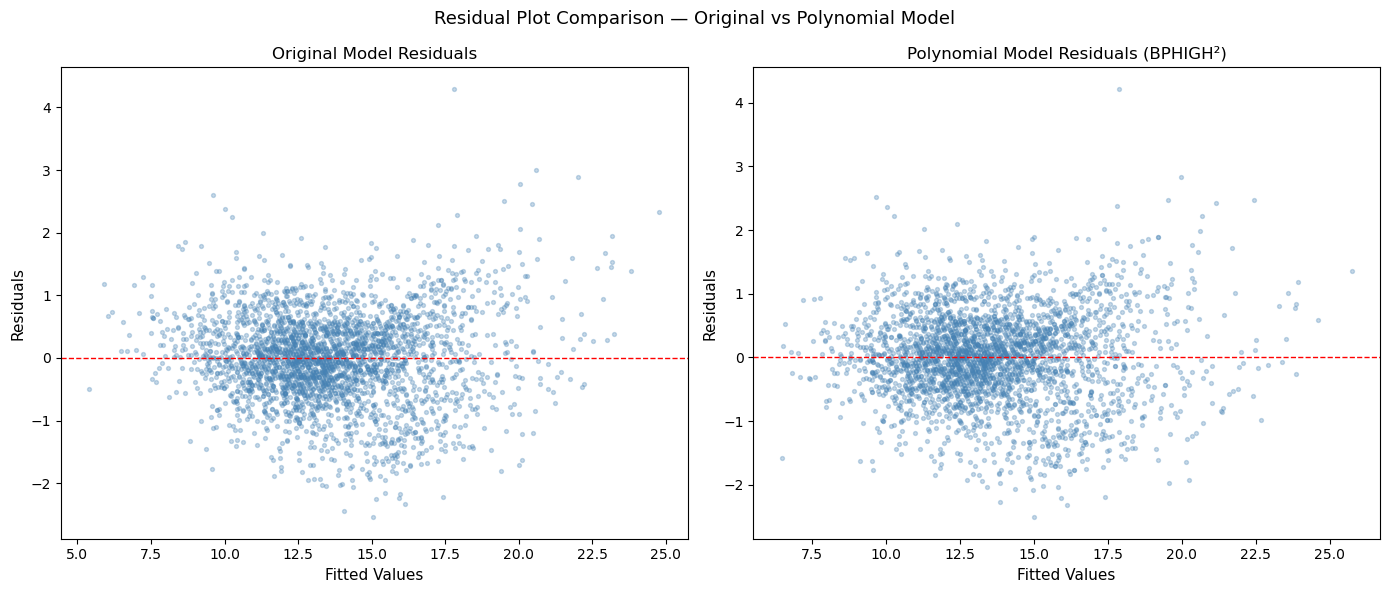

Chart saved


In [11]:
# Check residuals from the polynomial model
y_pred_poly_full = model_poly.predict(X_poly_scaled)
residuals_poly = y - y_pred_poly_full

# Plot residuals against fitted values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original model residuals
axes[0].scatter(y_pred_full, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='dashed', linewidth=1)
axes[0].set_title('Original Model Residuals', fontsize=12)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)

# Polynomial model residuals
axes[1].scatter(y_pred_poly_full, residuals_poly, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='dashed', linewidth=1)
axes[1].set_title('Polynomial Model Residuals (BPHIGH²)', fontsize=12)
axes[1].set_xlabel('Fitted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)

plt.suptitle('Residual Plot Comparison — Original vs Polynomial Model', fontsize=13)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\residual_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

## Model Selection — Linear vs Polynomial

| Model | R² | RMSE |
|-------|----|------|
| Original (linear) | 0.923 | 0.742 |
| Polynomial (BPHIGH²) | 0.925 | 0.736 |

The polynomial model shows modest improvement in both R² and RMSE, 
and the residual plot shows slight reduction in the U-shape pattern 
flagged in feature transformation. The improvement is analytically 
small but the polynomial term is retained as it addresses a known 
methodological concern and demonstrates appropriate model checking.

**Selected model: Polynomial (BPHIGH²)**

## Logistic Regression

Logistic regression predicts a binary outcome — in this case whether 
a county is above or below the national mean diabetes prevalence.

### Why Run This After Linear Regression
The linear model answers "how much does each factor contribute to 
diabetes prevalence?" The logistic model answers a different question: 
"what factors predict whether a county is a high-burden county?" 
Both are useful and complement each other.

### Binary Outcome Variable
Counties are classified as:
- 1 = High burden (diabetes prevalence above national mean of 13.64%)
- 0 = Low burden (at or below national mean)

### Output Interpretation
Logistic regression produces odds ratios rather than coefficients.
An odds ratio above 1.0 means the predictor is associated with 
higher odds of being a high-burden county. An odds ratio below 1.0 
means lower odds.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Create binary outcome variable
national_mean = df['DIABETES'].mean()
df['high_diabetes'] = (df['DIABETES'] > national_mean).astype(int)

print(f'National mean: {national_mean:.2f}%')
print(f'High burden counties (1): {df["high_diabetes"].sum()}')
print(f'Low burden counties (0): {(df["high_diabetes"] == 0).sum()}')
print(f'Split: {df["high_diabetes"].mean():.1%} high burden')

National mean: 13.64%
High burden counties (1): 1307
Low burden counties (0): 1649
Split: 44.2% high burden


In [13]:
# Check threshold values before setting up the comparison
mean_threshold = df['DIABETES'].mean()
p75_threshold = df['DIABETES'].quantile(0.75)
fixed_threshold = 15.0

print(f'Mean threshold: {mean_threshold:.2f}%')
print(f'75th percentile threshold: {p75_threshold:.2f}%')
print(f'Fixed threshold: {fixed_threshold:.2f}%')
print()

# Show how many counties fall into high burden under each threshold
for name, threshold in [('Mean', mean_threshold), 
                         ('75th percentile', p75_threshold),
                         ('15%', fixed_threshold)]:
    high = (df['DIABETES'] > threshold).sum()
    pct = high / len(df) * 100
    print(f'{name} ({threshold:.2f}%): {high} high-burden counties ({pct:.1f}%)')

Mean threshold: 13.64%
75th percentile threshold: 15.20%
Fixed threshold: 15.00%

Mean (13.64%): 1307 high-burden counties (44.2%)
75th percentile (15.20%): 720 high-burden counties (24.4%)
15% (15.00%): 784 high-burden counties (26.5%)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Define thresholds
thresholds = {
    'Mean (13.64%)': mean_threshold,
    '75th Percentile (15.20%)': p75_threshold
}

# Use the same polynomial predictor set as the linear model
X_log = df[predictors_poly]
scaler_log = StandardScaler()
X_log_scaled = scaler_log.fit_transform(X_log)

# Store results for comparison
results = {}

for name, threshold in thresholds.items():
    
    # Create binary outcome for this threshold
    y_binary = (df['DIABETES'] > threshold).astype(int)
    
    # Split into training and test sets
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X_log_scaled, y_binary, test_size=0.2, random_state=42
    )
    
    # Fit logistic regression
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    log_model.fit(X_train_l, y_train_l)
    
    # Evaluate on test set
    y_pred_l = log_model.predict(X_test_l)
    y_prob_l = log_model.predict_proba(X_test_l)[:, 1]
    auc = roc_auc_score(y_test_l, y_prob_l)
    
    results[name] = {
        'model': log_model,
        'auc': auc,
        'y_test': y_test_l,
        'y_pred': y_pred_l
    }
    
    print(f'\n{name}')
    print(f'AUC: {auc:.3f}')
    print(classification_report(y_test_l, y_pred_l))


Mean (13.64%)
AUC: 0.978
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       339
           1       0.93      0.93      0.93       253

    accuracy                           0.94       592
   macro avg       0.94      0.94      0.94       592
weighted avg       0.94      0.94      0.94       592


75th Percentile (15.20%)
AUC: 0.988
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       450
           1       0.90      0.84      0.87       142

    accuracy                           0.94       592
   macro avg       0.93      0.90      0.91       592
weighted avg       0.94      0.94      0.94       592



In [15]:
# Demographic-only model — no health measures as predictors
# Tests whether community characteristics alone predict high diabetes burden
predictors_demo = [
    'pct_black', 'pct_hispanic', 'pct_aian',
    'pct_below_poverty', 'median_household_income',
    'urban_rural_code'
]

X_demo = df[predictors_demo]
scaler_demo = StandardScaler()
X_demo_scaled = scaler_demo.fit_transform(X_demo)

# Run for both thresholds
results_demo = {}

for name, threshold in thresholds.items():
    
    # Create binary outcome
    y_binary = (df['DIABETES'] > threshold).astype(int)
    
    # Split into training and test sets
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X_demo_scaled, y_binary, test_size=0.2, random_state=42
    )
    
    # Fit logistic regression
    log_model_demo = LogisticRegression(max_iter=1000, random_state=42)
    log_model_demo.fit(X_train_d, y_train_d)
    
    # Evaluate
    y_pred_d = log_model_demo.predict(X_test_d)
    y_prob_d = log_model_demo.predict_proba(X_test_d)[:, 1]
    auc_d = roc_auc_score(y_test_d, y_prob_d)
    
    results_demo[name] = {
        'model': log_model_demo,
        'auc': auc_d,
        'y_test': y_test_d,
        'y_pred': y_pred_d
    }
    
    print(f'\n{name}')
    print(f'AUC: {auc_d:.3f}')
    print(classification_report(y_test_d, y_pred_d))


Mean (13.64%)
AUC: 0.871
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       339
           1       0.78      0.72      0.75       253

    accuracy                           0.79       592
   macro avg       0.79      0.78      0.79       592
weighted avg       0.79      0.79      0.79       592


75th Percentile (15.20%)
AUC: 0.910
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       450
           1       0.79      0.61      0.69       142

    accuracy                           0.87       592
   macro avg       0.84      0.78      0.80       592
weighted avg       0.86      0.87      0.86       592



## Logistic Regression — Model Comparison

### Full Model (health measures + demographics)
- Includes BPHIGH, OBESITY, LPA, HIGHCHOL alongside race, 
  poverty, income, and urban/rural status
- AUC: 0.978 (mean threshold), 0.988 (75th percentile)
- Limitation: health measures co-occur with diabetes, creating 
  circularity in prediction

### Demographic-Only Model
- Includes only race composition, poverty, income, urban/rural status
- AUC: 0.871 (mean threshold), 0.910 (75th percentile)
- More analytically honest test of structural prediction

### Key Finding
Structural community characteristics alone (race, poverty, income, 
geography) predict high diabetes burden counties with AUC of 0.871-0.910.
This confirms that diabetes burden is systematically distributed across 
structural lines, not randomly distributed across communities.

The drop in recall for the 75th percentile demographic model (0.61) 
indicates that the most extreme high-burden counties have 
characteristics beyond what demographics alone can capture — 
likely reflecting compounding disadvantages not fully measured 
in this dataset.

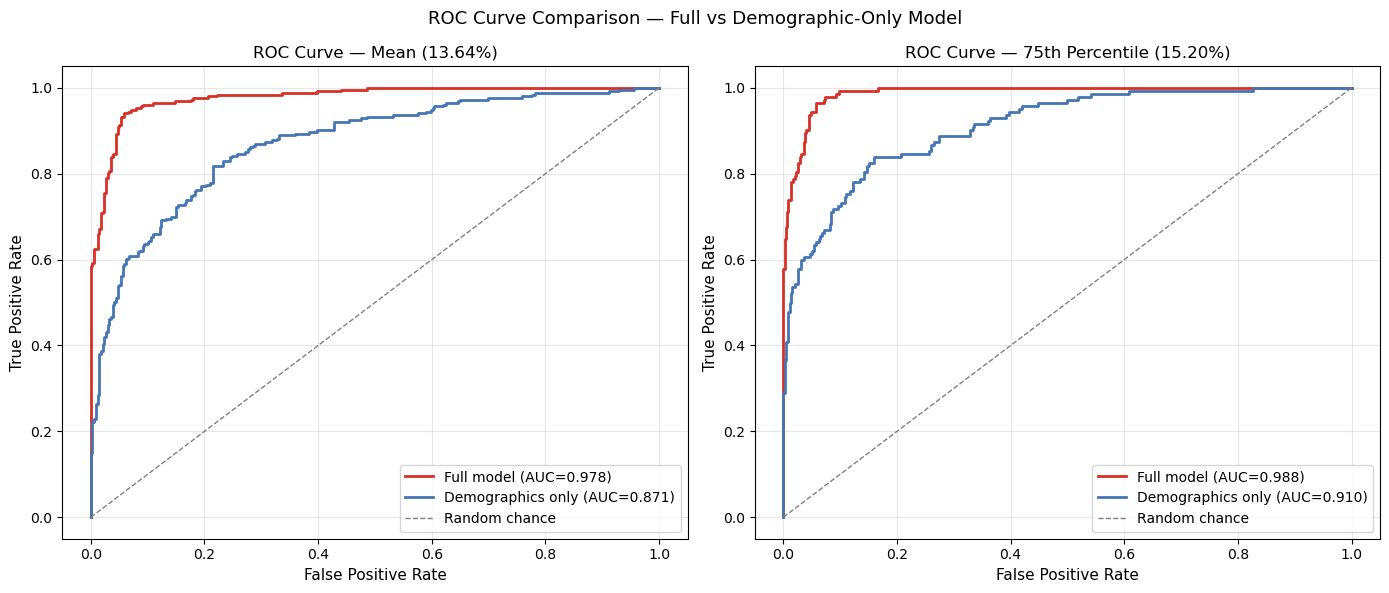

Chart saved


In [16]:
from sklearn.metrics import roc_curve

# Calculate ROC curves for all four models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define models and labels for each threshold
threshold_names = ['Mean (13.64%)', '75th Percentile (15.20%)']

for i, name in enumerate(threshold_names):
    ax = axes[i]
    
    # Full model ROC curve
    y_binary = (df['DIABETES'] > list(thresholds.values())[i]).astype(int)
    
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X_log_scaled, y_binary, test_size=0.2, random_state=42
    )
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    log_model.fit(X_train_l, y_train_l)
    y_prob_full = log_model.predict_proba(X_test_l)[:, 1]
    fpr_full, tpr_full, _ = roc_curve(y_test_l, y_prob_full)
    auc_full = roc_auc_score(y_test_l, y_prob_full)
    
    # Demographic-only model ROC curve
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X_demo_scaled, y_binary, test_size=0.2, random_state=42
    )
    log_model_demo = LogisticRegression(max_iter=1000, random_state=42)
    log_model_demo.fit(X_train_d, y_train_d)
    y_prob_demo = log_model_demo.predict_proba(X_test_d)[:, 1]
    fpr_demo, tpr_demo, _ = roc_curve(y_test_d, y_prob_demo)
    auc_demo = roc_auc_score(y_test_d, y_prob_demo)
    
    # Plot both curves
    ax.plot(fpr_full, tpr_full, color='#d73027', linewidth=2,
            label=f'Full model (AUC={auc_full:.3f})')
    ax.plot(fpr_demo, tpr_demo, color='#4575b4', linewidth=2,
            label=f'Demographics only (AUC={auc_demo:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='dashed', 
            linewidth=1, label='Random chance')
    
    ax.set_title(f'ROC Curve — {name}', fontsize=12)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curve Comparison — Full vs Demographic-Only Model', 
             fontsize=13)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\roc_curves.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

## Findings — ROC Curve Comparison

Both models substantially outperform random chance across both thresholds.

The gap between the full model (red) and demographic-only model (blue) 
represents the predictive contribution of the health measures. The 
demographic-only model's strong performance (AUC 0.871-0.910) confirms 
that structural community characteristics are powerful independent 
predictors of high diabetes burden.

The staircase pattern in the blue curve reflects that the demographic 
model makes larger classification jumps at certain thresholds rather 
than smoothly separating the classes, suggesting the relationship 
between demographics and diabetes burden is not uniformly linear 
across the full distribution of counties.

## Summary — Multivariate Analysis Findings

### Linear Regression (Outcome: Continuous Diabetes Prevalence)

| Model | R² | RMSE |
|-------|----|------|
| Original linear | 0.923 | 0.742 pp |
| Polynomial (BPHIGH²) | 0.925 | 0.736 pp |

**Key coefficients (polynomial model, standardized):**
- BPHIGH is the strongest independent predictor (1.568)
- pct_hispanic emerges as second strongest (0.596) — masked in 
  bivariate analysis by correlations with other predictors
- pct_below_poverty (0.446) outperforms median_household_income 
  (-0.024) as the income measure
- OBESITY is weak after controlling for other factors (0.128)
- urban_rural_code is modest (0.093), supporting the hypothesis 
  that income mediates much of the rural penalty

### Logistic Regression (Outcome: Binary High Burden)

| Model | Threshold | AUC | Accuracy | Recall (High) |
|-------|-----------|-----|----------|--------------|
| Full | Mean | 0.978 | 94% | 0.93 |
| Full | 75th pct | 0.988 | 94% | 0.84 |
| Demographics only | Mean | 0.871 | 79% | 0.72 |
| Demographics only | 75th pct | 0.910 | 87% | 0.61 |

### Core Finding
Structural community characteristics (race, poverty, income, geography) 
alone predict high diabetes burden counties with AUC of 0.871-0.910. 
This confirms that diabetes burden is systematically distributed along 
structural lines rather than randomly across communities.

The full model's higher AUC reflects circularity — health measures 
that co-occur with diabetes were included as predictors. The 
demographic-only model is the more analytically defensible test 
of structural prediction.

### Methodological Notes
- BPHIGH non-linearity addressed with polynomial term (modest improvement)
- Remaining heteroscedasticity noted as a limitation
- Cross-sectional data — findings are associational, not causal
- Ecological analysis — county-level findings do not imply 
  individual-level relationships